# Configuration Parameters

Located under /inputfiles

## General Parameters

Where have you stored the PlatoSim software?

    export PLATO_PROJECT_HOME=<full path to the PlatoSim3 directory>

General:

    ProjectLocation:             ENV['PLATO_PROJECT_HOME']

## Observing Parameters

ObservingParameters:

    MissionDuration:  6.5                                # Total duration of the mission [yrs]
    NumExposures:     10                                 # Number of expsosures
    BeginExposureNr:  0                                  # Sequential number of 1st exposure (for Slurm)
    ExposureTime:     21                                 # Exposure time [s]
    RApointing:       180                                # Right ascension of platform pointing [degrees] 
    DecPointing:      -70                                # Declination of platform pointing [degrees]
    Fluxm0:           1.00179e8                          # Photon flux of a V=0 G2V-star [photons / s / m^2 / nm]
    StarCatalogFile:  inputfiles/starField_RA180Dec-70.txt

#### Spacecraft pointing

The pointing of the spacecraft is the pointing of the platform, and is not identical to the pointing of the telescope (i.e. the optical axis).

#### Fluxm0

Calculation of the flux $F_{phot}$ of a star:

$$F_{phot} = t_{exposure} \cdot F_0 \cdot T_{\lambda} \cdot Q_{\lambda} \cdot A \cdot 10^{-0.4 m_{\lambda}} $$

#### Star Catalogue

One line per source:
- right ascension [degrees]
- desclination [degrees]
- magnitude

## Sky Parameters

#### SkyBackground

Uniform background contribution over the whole sub-field:
- positive: stellar + zodiacal background level [photons / pixel  / s]
- negative: computed automatically, based on:
    - position in the sky
    - throughput passband (central wavelength & width)
    - light-collecting area of the telescope
    - plate scale
    - exposure time

## Platform Parameters

Platform:

    UseJitter:                   yes             # yes or no. If no, ignore everything below.
    UseJitterFromFile:           no              # yes or no. If yes, ignore RMS and timescale below.
    JitterYawRms:                1.0             # [arcsec]
    JitterPitchRms:              1.0             # [arcsec]
    JitterRollRms:               1.0             # [arcsec]
    JitterTimeScale:             3600.           # [s]
    JitterFileName:              inputfiles/jitter.txt

#### Jitter

Pointing variations of the spacecraft (platform), described in terms of Euler angles (yaw, pitch, roll).

<img src="SpacecraftCoordinateSystem.png">

##### From File

One line per jitter step:
- time [s]
- step in yaw [arcsec]
- step in pitch [arcsec]
- step in roll [arcsec]

##### Jitter Parameters

- standard deviation of normal distribution describing (yaw, pitch, roll) step
- timescale

Jitter noise will be generated in the time domain with the following power spectral density:

$$P(\nu) = \frac{\sigma^2 \tau}{1 + (2\pi\nu\tau)^2}$$

where $\sigma$ is the VarScale, and $\tau$ is the TimeScale.

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (11, 10)

In [2]:
import os
baseDir    = os.getenv("PLATO_PROJECT_HOME")
currentDir = os.getcwd()

import sys
sys.path.append(baseDir + "/python")

(0.03, 5)

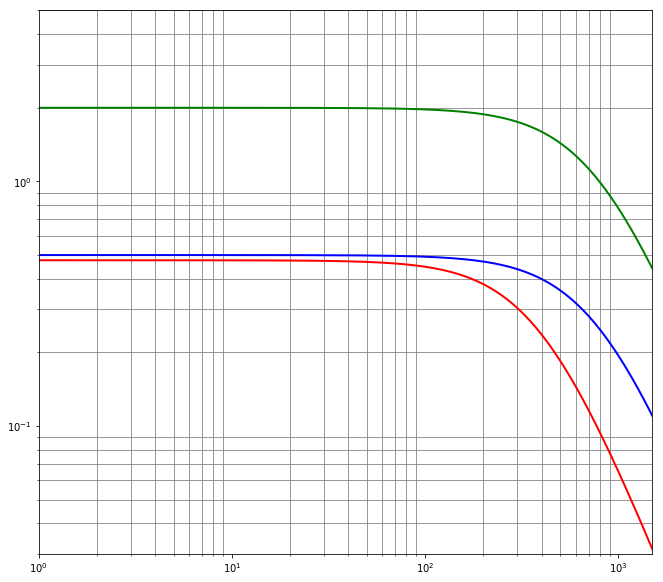

In [3]:
from numpy import *
from matplotlib import pyplot as plt
import noise
freq = linspace(1.0, 1500.0, 200)                                                   # [Ms]
plt.loglog(freq, noise.rednoiseModel(freq, [200e-6], [ 50.0]), c="b", linewidth=2)  # Tau = 200s [Ms], Sigma = 50 ppm
plt.loglog(freq, noise.rednoiseModel(freq, [400e-6], [ 34.5]), c="r", linewidth=2)  # Tau = 400s [Ms], Sigma = 34 ppm
plt.loglog(freq, noise.rednoiseModel(freq, [200e-6], [100.0]), c="g", linewidth=2)  # Tau = 200s [Ms], Sigma = 100 ppm
plt.grid(True, which='minor', axis='both', linestyle='-', color='gray')
plt.xlim(1.0, 1500)
plt.ylim(0.03, 5)

## Telescope Parameters

# Telescope:

    GroupID:                     Custom          # Custom camera group
    AzimuthAngle:                0.0             # Azimuth angle of telescope on the platform [deg]
    TiltAngle:                   0.0             # Tilt angle of the telescope on the platform [deg]
    LightCollectingArea:         113.1           # Effective area of 1 telescope [cm^2]
    TransmissionEfficiency:
         BOL:                    0.7821          # Transmission efficiency at BOL
         EOL:                    0.7666          # Transmission efficiency at EOL (linear degradation)
    UseDrift:                    no              # yes or no. If no, ignore everything below.
    UseDriftFromFile:            no              # yes or no. If yes: ignore RMS and timescale below
    DriftYawRms:                 2.0             # RMS of thermo-elastic drift in yaw [arcsec]
    DriftPitchRms:               2.0             # RMS of thermo-elastic drift in pitch [arcsec]
    DriftRollRms:                2.0             # RMS of thermo-elastic drift in roll [arcsec]
    DriftTimeScale:              86400.          # Timescale of thermo-elastic drift [s]
    DriftFileName:               inputfiles/drift.txt

#### Tilt & Azimuth

The telescope pointing (i.e. optical axis) can be derived from the platform pointing, and the tilt and azimuth angle.

In case GroupID = Custom, the values for the tilt and azimuth angle will be read from the "Telescope" block.  In case of a pre-defined camera group (i.e. GroupID = 1, 2, 3, 4, or Fast), the appropriate values will be selected from the "CameraGroups" block (see below).

<img src="tiltAzimuth.png">

#### Drift

Thermo-elastic instability of the telescope on the platform.

Similar to telescope jitter:
- from file
- drift parameters

## Camera Parameters

Camera:
    
    FocalPlaneOrientation:
        Source:                 ConstantValue   # ConstantValue (constant in time) or FromFile (time dependent)
        ConstantValue:          0.0             # [degrees] if ConstantValue
        FromFile:               inputfiles/fporientation.txt  # If FromFile: (time [s], FP orientation [deg])
    
    PlateScale:                 0.8333          # Plate scale [arcsec/micron]
    FocalLength: 
        Source:                 ConstantValue   # ConstantValue (constant in time) or FromFile (time dependent) 
        ConstantValue:          0.24752         # If ConstantValue (from ZEMAX model) [m]
        FromFile:               inputfiles/focallength.txt # If FromFile: time [s] & focalLenght [m]
    ThroughputLambdaC:           550             # Central wavelength of the throughput passband [nm]
    ThroughputBandwidth:             498         # FWHM [nm]
    IncludeAberrationCorrection: yes             # Whether or not to include differential aberration correction
    AberrationCorrection:
        Type:                        differential # [differential, absolute]
    IncludeFieldDistortion:      yes              # Whether or not to include field distortion
    FieldDistortion:
        Type:                        Polynomial1D    # The model for the field distortion
        Source:                      FromFile        # ConstantValue (constant in time) or FromFile (time dependent) 
        ConstantCoefficients:        [-0.0036696919678, 1.0008542317, -4.12553764817e-05, 5.7201219949e-06]
        ConstantInverseCoefficients: [-0.00458067036444, 1.00110311283, -5.61136295937e-05, -4.311925329e-06]
        CoefficientsFromFile:        inputfiles/distortioncoefficients.txt
        InverseCoefficientsFromFile: inputfiles/distortioninversecoefficients.txt

#### Focal-Plane Orientation

<img src="FocalPlaneCoordinateSystem.png">

#### Field Distortion

Image magnification increases with distance from the optical axis of the telescope.

- as 1D polynomial:

$$P(x) = c_{0} + c_{1} \cdot x + c_{2} \cdot x^{2} + ... + c_{n} \cdot x^{n}$$

- as 2D polynomial:

$$P(x, y) = c_{00} + c_{10} \cdot x + ... + c_{n0} \cdot x^{n} + c_{01} \cdot y      + ... + c_{0n} \cdot y^{n} + c_{11} \cdot x \cdot y + c_{12} \cdot x \cdot y^{2}      + ... + c_{1(n - 1)} \cdot x \cdot y^{n - 1} + ... + c_{(n - 1)1} \cdot x^{n - 1} \cdot y$$

## PSF Parameters

PSF:

    Model:              MappedGaussian  # Select the model to be used for the PSF 
                                        # [MappedGaussian, MappedFromFile, AnalyticGaussian, AnalyticNonGaussian]
    MappedGaussian:                     # Generate the PSF from a 2D Gaussian function
      Sigma:            0.641           # Standard deviation of Gaussian PSF [pixels]
      NumberOfPixels:   8               # The number of pixels in the field for which the PSF is generated
    MappedFromFile:                     # Read a pre-calculated PSF from an HDF5 file
      Filename:         inputfiles/psf.hdf5 
      DistanceToOA:     -1              # Angular distance to the optical axis. -1 to auto-compute. [deg]
      RotationAngle:    -1              # Rotation angle w.r.t the focal-plane x-axis. -1 to auto-compute. [deg]
      NumberOfPixels:   8               # The number of pixels in the field for which the PSF is generated
    AnalyticGaussian:                   # Elongated 2D Gaussian, changing in size over the FOV
      Sigma00:          1.0             # Std.dev. at the optical axis (OA)
      SigmaX18:         5.0             # Std.dev. in the x-direction at 18 degrees from the OA
      SigmaY18:         2.0             # Std.dev. in the y-direction at 18 degrees from the OA
    AnalyticNonGaussian:
        ParameterFileName:           inputfiles/psfallv3.txt
        Sigma:                       # Width of the analytic PSF, equal to sigma for a Gaussian PSF [pix]  
            Source:                  ConstantValue   # ConstantValue (constant in time) or FromFile (time dependent) 
            ConstantValue:           0.5             # If ConstantValue  [pix]
            FromFile:                inputfiles/sigmaPSF.txt # If = FromFile: time [s] & sigma_PSF [pix]

#### Pre-Computed PSF

Download from the FTP-server.

## FEE Parameters

FEE:

    NominalOperatingTemp:   210.15     # Nominal operating temperature of the FEE
    ReadoutNoise:           35.2       # Readout noise for the FEE [e-/pixel]
    Gain:
      RefValueLeft:         0.0278     # Reference value at the nominal operating temperature of ADC1 [ADU/µV]
      RefValueRight:        0.0278     # Reference value at the nominal operating temperature of ADC2 [ADU/µV]
      AllowedDifference:    0.0        # Allowed difference between the gain value of ADC1 and ADC2 [%]
      Stability:            -100.0e-6  # Change in gain with temperature [ADU/µV/K]
    ElectronicOffset:
      RefValue:             1000       # Reference value at the nominal operating temperature of the FEE [ADU/pixel]
      Stability:            1          # Change in offset with temperature [ADU/pixel/K]

## CCD Parameters

CCD:

    Position:                    Custom          # Custom CCD position
    OriginOffsetX:               0               # X Offset of CCD origin from center of focal plane [mm]
    OriginOffsetY:               0               # Y Offset of CCD origin from center of focal plane [mm]
    Orientation:                 0               # Orientation of CCD w.r.t. focal plane orientation [deg]
    NumColumns:                  4510            # Number of columns [pixels]
    NumRows:                     4510            # Number of rows [pixels]
    PixelSize:                   18              # Pixel size [micron]
    BFE:
        Range:                   2           # How far pixels can be apart and still influence each other [pixels]
        p0:                      0.05        # Value for p0 parameter in Eq. (18) in Guyonnet et al. 2015
        p1:                      0.15        # Value for p1 parameter in Eq. (18) in Guyonnet et al. 2015
        RefFlux:                 1e6         # Reference flux for BFE [e-]
    Gain:
      RefValueLeft:              1.80            # Reference value at the nominal operating temperature of the left-hand side of the CCD [µV/e-]
      RefValueRight:             1.80            # Reference value at the nominal operating temperature of the right-hand side of the CCD [µV/e-]
      Stability:                 -0.004          # [microV/e-/K]
      AllowedDifference:         15.0            # Allowed difference between the gain value of both detector halves [%]
    QuantumEfficiency:
      Efficiency:                0.925           # Quantum efficiency at reference angle
      RefAngle:                  45.0            # Reference angle for QE [degrees]
      ExpectedValue:             0.993           # Expected value for QE over the entire CCD
    FullWellSaturation:          90000 0         # Readout noise [e-/pixel]
    DigitalSaturation:           65535           # E.g. 16 bit [ADU/pixel]
    ReadoutNoise:                33.5            # [e-/pixel]
    ReadoutTime:                 2               # time to read out entire CCD [s]
    FlatfieldPtPNoise:           0.010           # peak-to-peak pixel noise
    Vignetting:
      ExpectedValue:             0.945           # Expected value for vignetting over the entire CCD
     Polarization:
      Efficiency:                0.978           # Throughput efficiency caused by polarisation at the reference angle
      RefAngle:                  18.8875         # Reference angle for polarisation [degrees]
      ExpectedValue:             0.989           # Expected value (mean of all detector pixels)
    Contamination:
      ParticulateContaminationEfficiency: 0.972     # Throughput efficiency due to particulate contamination
      MolecularContaminationEfficiency:   0.9573    # Throughput efficiency due to molecular contamination
    DarkSignal:
      DarkCurrent:               1.2              # Dark current [e- / s]
      DSNU:                      10.0             # Dark signal non-uniformity [%]
    CTI:
      Model:                     Simple
      Simple:
            MeanCTE:                     0.99999         # Mean Charge Transfer Efficiency
      Short2013:
            Beta:                    0.37                # beta exponent in Short et al. (2013)
            Temperature:             203.                # [K]
            NumTrapSpecies:          4                   # number of different trap species
            TrapDensity:             [9.8, 3.31, 1.56, 13.24]                   # for each trap species [traps/pixel]
            TrapCaptureCrossSection: [2.46e-20, 1.74e-22, 7.05e-23, 2.45e-23]     # for each trap species [m^2]
            ReleaseTime:             [2.37e-4, 2.43e-2, 2.03e-3, 1.40e-1]         # for each trap species [s]
    NominalOperatingTemp:        203.15          # Nominal operating temperature of the CCD
    IncludeFlatfield:            yes             # Include flatfield [yes or no]
    IncludeDarkSignal:           yes             # Include dark signal [yes or no]
    IncludeBFE:                  yes             # Include BFE [yes or no]
    IncludePhotonNoise:          yes             # Include photon noise [yes or no]
    IncludeReadoutNoise:         yes             # Include readout noise [yes or no]
    IncludeCTIeffects:           yes             # Include charge transfer inefficiency effects [yes or no]
    IncludeOpenShutterSmearing:  yes             # Include trails due reading out with an open shutter [yes or no]
    IncludeQuantumEfficiency:    yes             # Include QE
    IncludeVignetting:           yes             # Include brightness attenuation towards the edge of the FOV
    IncludePolarization:         yes             # Include loss of throughput due to polarisation
    IncludeParticulateContamination: yes         # Include loss of throughput due to particulate contamination
    IncludeMolecularContamination:   yes         # Include loss of throughput due to molecular contamination
    IncludeConvolution:          yes             # Whether or not to convolve the subPixelMap with the PSF
    IncludeFullWellSaturation:   yes             # Whether or not full-well saturation should be applied
    IncludeDigitalSaturation:    yes             # Whether or not digital saturation should be applied
    WriteSubPixelImagesToHDF5:   no              # Only use this for a limited number of exposures

#### CCD Reference Frame
In case position = Custom, the values for the origin offse, orientation, dimensions, and first illuminated row will be read from the "CCD" block.  In case of a pre-defined CCD position (i.e. GroupID = 1, 2, 3, or 4), the appropriate values will be selected from the "CCDPositions" block (see below).  Note that the butting distance (here: 2 mm) has not been updated (to 2.6 mm) yet in this figure.

<img src="FocalPlaneCoordinateSystem.png">

#### Quantum Efficiency

Angle-dependent ratio of the number of collected electrons to the number of incident photons.

#### Brighter-Fatter Effect (BFE)

Size of the PSF increases for brighter sources.

#### Gain

Relates the number of electrons per pixels to the number of ADUs.

Note that the gain has a contribution from the front-end-electronics (FEE) and the detector.  The gain is different for both ADCs (of the FEE) and for both detector halves.

#### Polarisation

Angle-dependent loss in throughput efficiency due to polarisation.

#### Contamination

Angle-dependent loss in throughput efficiency due to particulate and molecular contamination.

#### Vignetting

Angle-dependent brightness attenuation towards the edge of the FOV due to vignetting.

#### Saturation

##### Full-Well Saturation (Blooming)

Excess electrons get transferred up and down to other pixels in the same column.

##### Digital Saturation

Pixel values topped off at given saturation limit.

#### Readout Noise

Occurs due to the imperfect nature of the CCD amplifiers. When the electrons are transferred to the amplifier, the induced voltage is measured. However, this measurement is not perfect, but gives a value which is on average too high by an amount of the readout noise, with the squareroot of the readout noise as standard deviation.

Note that the readout noise of the FEE and the detector are added in quadrature.

#### Flatfield
Accounts for the differences in sensitivity across the detector (1/f spatial distribution).

#### Dark Signal

The relatively small electric current that flows in the CCD when not photons enter the device.

#### CTI Effects

Because of detector defects, electrons can get trapped in the readout process. The trapped charge ends up getting dissociated from its original pixel and eventually gets released into another pixel. The result is that the original image gets smeared out in the direction away from the readout amplifier (visible in the appearance of "charge trails"). This is known as imperfect CTE (Charge-Transfer Efficiency) or alternatively as CTI (Charge-Transfer Inefficiency). The fraction of the charge that is successfully transferred from one row to the next row is expressed by this parameter.

#### Photon noise

Due to the discrete/quantised nature of the electronic charge carried by the e- (when counting them as representatives of photons hitting the detectors).  Implemented as Poisson distribution with the pixel value as mean (each pixel is treated independently).

## Sub-field Parameters

SubField:

    ZeroPointRow:                0               # Row of the (0,0) pixel of the sub-field [pixels]
    ZeroPointColumn:             0               # Column of the (0,0) pixel of the sub-field [pixels]
    NumColumns:                  100             # Number of columns, should be >= 8 [pixels]
    NumRows:                     100             # Number of rows, should be >= 8 [pixels]
    NumBiasPrescanRows:          5               # Nr of rows in pre-scan strip to determine the bias [pixels]
    NumSmearingOverscanRows:     5               # Nr rows in over-scan strip to determine the smearing [pixels]
    SubPixels:                   8               # (Sqrt of) nr of subpixels per CCD pixel. Should be 2^n <= 128.

## Random Seeds

RandomSeeds:

    ReadOutNoiseSeed:            1424949740
    PhotonNoiseSeed:             1433320336
    JitterSeed:                  1433320381
    FlatFieldSeed:               1425284070
    DriftSeed:                   1433429158
    CosmicSeed:                  1494750830
    DarkSignalSeed:              1468838669

## CameraGroups
Don't alter these parameters!

Depending on the value of the "GroupID" parameter in the "Telescope" block, the appropriate value will be selected.

    CameraGroups:
        AzimuthAngle:   [45.0, 135.0, -135.0, -45.0, 0.0]
        TiltAngle:      [9.2, 9.2, 9.2, 9.2, 0.0]

## CCDPositions
Don't alter these parameters!

Depending on the value of the "Position" parameter in the "CCD" block, the appropriate value will be selected.

    CCDPositions:
        OriginOffsetX:                   [-1.3, -1.3, -1.3, -1.3]
        OriginOffsetY:                   [82.18, 82.18, 82.18, 82.18]
        Orientation:                     [0, 90, 180, 270] 
        NumColumns:                      [4510, 4510, 4510, 4510]
        NumRows:                         [4510, 4510, 4510, 4510]
        FirstRowForNormalCamera:         [0, 0, 0, 0]
        FirstRowForFastCamera:           [2255, 2255, 2255, 2255]

Depending on the value of the "GroupID" parameter in the "Telescope" block, the first illuminated row will be different:
* normal camera (GroupID = 1, 2, 3, or 4): the whole CCD is illuminated
* fast camera (GroupID = Fast): only the upper half of the CCD is illuminated